# Decomposition Functions

The functions detailed in this section are involved in the decomposition, cleaning and reconstruction process for the electron lattice data. This is where unsupervised machine learning (UML) is applied, and is the basis of much of the computational interest in the project. The functions designed use the Hyperspy package for decomposition, and can apply different UML algorithms, although single value decomposition (SVD) is the most commonly used in the project.

In [1]:
# Required function imports
import os
import numpy as np
import matplotlib.pyplot as plt
import hyperspy.api as hs

# Importing the section relevant functions
import ACPP_Bunjy.decomp as decomp

## Auto Import

The first function is a utility function to efficently process a file into workable data of the correct format, then to be passed to the following functions. The function takes the fileneame as an input and returns a correctly formatted dataset, in form of an hs.signals.Signal1D object. Optionally, the dataset can be cropped from its original size for more efficient testing and processing. The details of inputs and outputs are shown below.

     Parameters
    ----------
    filename: str
        Name of the file to be imported, not including directory path
    crop : tuple of slices, optional
        Cropping instructions, e.g. (slice(0,10), slice(0,10), slice(None)) will return a crop of [0:10,0:10,:].
        Function will not crop and return full dataset as default.

    Returns
    -------
    cropped_data: hs.signals.Signal1D
        Correctly unpackaged raw data of desired size.
    """

In general for this project, auto_import should always be the first function ran on a new dataset before further analysis.

In [2]:
# Defining the example filename and desired crop
fn = '/014_lsmo_lfo_sto_interface_domain_wall_long_side_holz_fast_PT1D.npy'
crop = (slice(0,25),slice(0,25),slice(None))

# Unpackaging data with auto_import function
data_ex = decomp.auto_import(fn,crop=crop)

WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)


In [3]:
# Chechking that the auto_import function has created a dataset of the correct type and shape
data_ex

<Signal1D, title: , dimensions: (25, 25|360)>

## Auto Decomp

This is the primary function of this section which applies a decomposition to the formatted dataset and reconstructs with a desired number of vector components.

Decomposition takes a given signal and with a machine learning algorithm will determine a set of vector components most likely to make up that signal. In a real physical signal, most of these components will represent noise or artefacts, so the cleaning process then involves recombining the set of vectors that represents physically significant information, while eliminating 'noise vectors'. The correct number of vectors to use in reconstruction is based on analysis of a scree plot, which shows how much variance is retained from the signal by each component, and by examining key metrics of the reconstructed data in comparison to the raw (see following section). The primary algorithm used for this goal is singular value decomposition (SVD), which decomposes a dataset as follows:

\begin{equation}
    M=USV^T \rightarrow M_{clean}=U_kS_kV_k^T  
\end{equation}

$V$ is the set of vector components, equivalent to the set of basis vectors for constructing $M$. $U$ is the individual components of each vector for every point in the $M$ dataset, and $S$ is the weighting of each vector contribution to the original matrix $M$. By examining the values of $S$ against index $k$ (known as a Scree plot), the vectors of importance can be identified corresponding to the highest $S$ values, and a cleaned version of the signal reconstructed from the top $k^{th}$ desired vectors.

Along with the input data and number of vectors, the function takes optional arguments for the decomposition algorithm to use (SVD is the default), the output_dimension desired for the decomposed data (necessary for using certain decomposition models), and toggles to print three metrics of goodness, and plot the reconstructed data within the Hyperspy framework. The input and output arguments of the function are listed below:

    Parameters
    ----------
    input_data: hs.signals.Signal1D
        Input raw data for decomposition, formatted in Hyperspy signal form.
    vectors: int
        Desired vectors to be used for signal reconstruction, for which all vectors up to the int value will be used.
    algorithm: str, default='SVD'
        The algorithm to be used by Hyperspy for decomposition, see Hyperspy documentation for details.
    output_dimension: int, default='None'
        The number of output components desired from decomposition, required for operation of other non-SVD algorithms in
        Hyperspy. None as default for use with SVD, which will give an output_dimension of 360.
    metrics: bool, optional
        Argument to return metrics for evaluation of algorithm performance, including RRE, EVR, and NSM.
    plots: bool, optional
        Argument to plot decomposition and scree plot in the Hyperspy framework, again see HS documentation.

    Returns
    -------
    cleaned_data: hs.signals.Signal1D
        Reconstructed data using set vectors, with noise removed.
    metrics_list: list
        List of the three calculated goodness metrics.

Decomposition info:
  normalize_poissonian_noise=False
  algorithm=SVD
  output_dimension=None
  centre=None
Relative reconstruction error: 0.15882891074204716
Explained variance ratio: 0.9747733771124947
Noise suppression metric: 0.6768237263524621


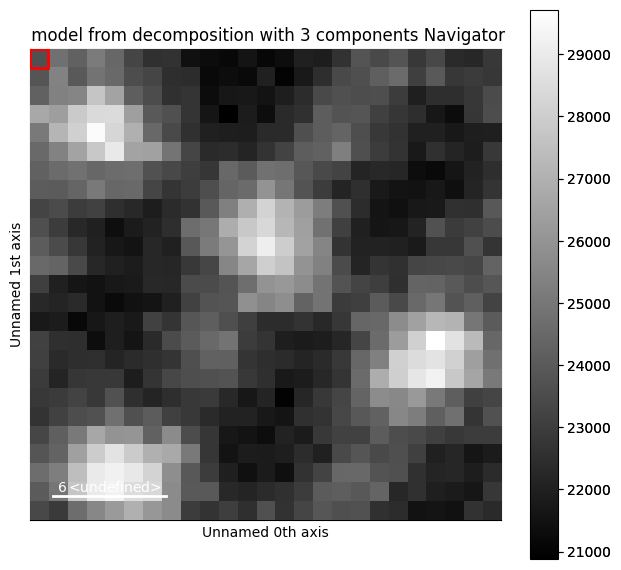

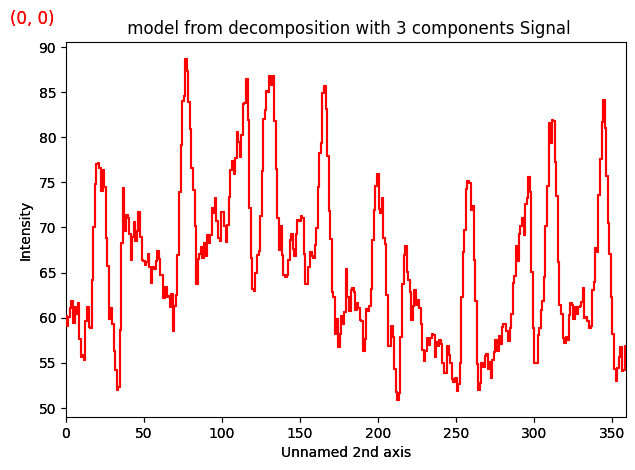

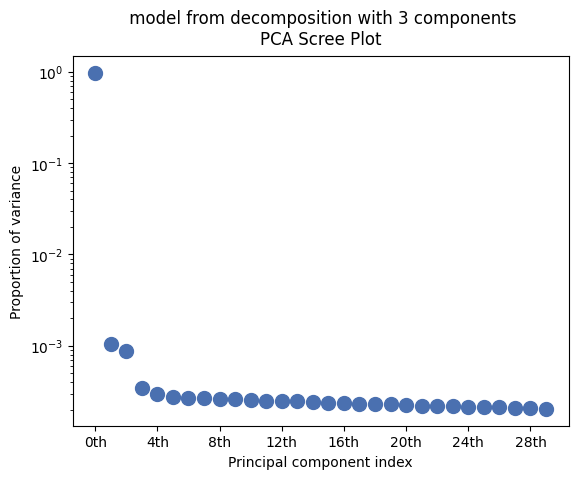

In [11]:
# Setting number of vectors for reconstruction
vectors = 3

# Running auto decomp algorithm, with metrics and plots enabled
clean_ex = decomp.auto_decomp(data_ex, vectors, metrics=True, plots=True)

Other algorithms can be implemented for decomposition based on the Hyperspy framework (see https://hyperspy.org/hyperspy-doc/current/user_guide/mva/decomposition.html for info). Below is an example using the principal component analysis (PCA) algorithm from sklearn.

Decomposition info:
  normalize_poissonian_noise=False
  algorithm=sklearn_pca
  output_dimension=None
  centre=None
scikit-learn estimator:
PCA()
Relative reconstruction error: 0.1584277225669225
Explained variance ratio: 0.24173672779739044
Noise suppression metric: 0.6784581495658437


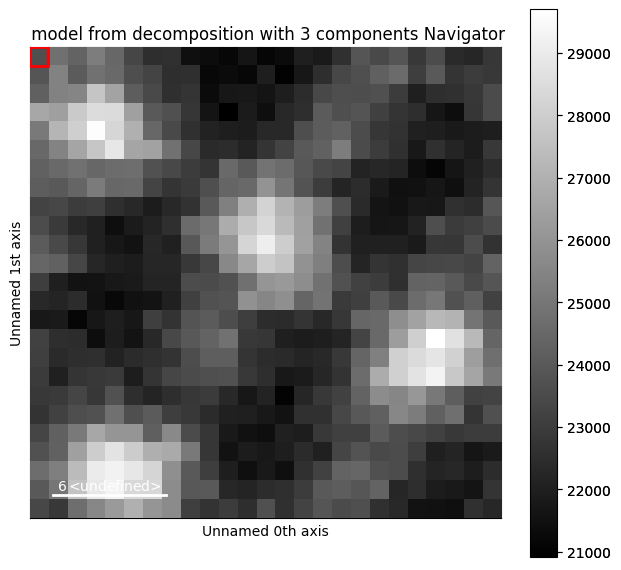

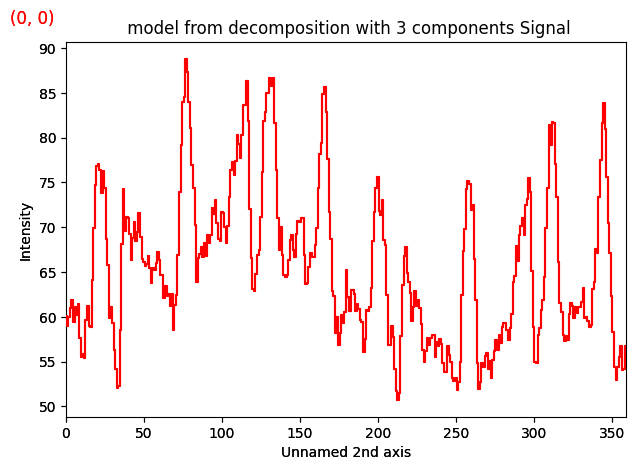

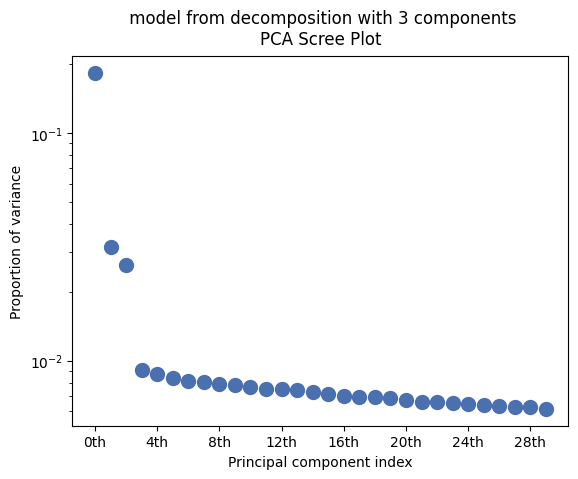

In [9]:
# Setting number of vectors for reconstruction
vectors = 3

# Running auto decomp algorithm, with metrics and plots enabled
clean_ex_pca = decomp.auto_decomp(data_ex, vectors, algorithm="sklearn_pca", metrics=True, plots=True)

Algorithms other than SVD and sklearn_pca can be used but have limitations in their returns due to the loss of the get_explained_variance_ratio function for these models. Namely, the calculation of the EVR metric, and Scree plotting no longer become possible with other models, however all other functions perform as expected. Below is an example utilizing the Non-negative matrix factorization (NMF) model:

Decomposition info:
  normalize_poissonian_noise=False
  algorithm=NMF
  output_dimension=5
  centre=None
scikit-learn estimator:
NMF(n_components=5)
Relative reconstruction error: 0.8518678854641927
EVR Metric is unavailable for NMF
Noise suppression metric: 0.4701768237214198
Scree Plot is unavailable for NMF


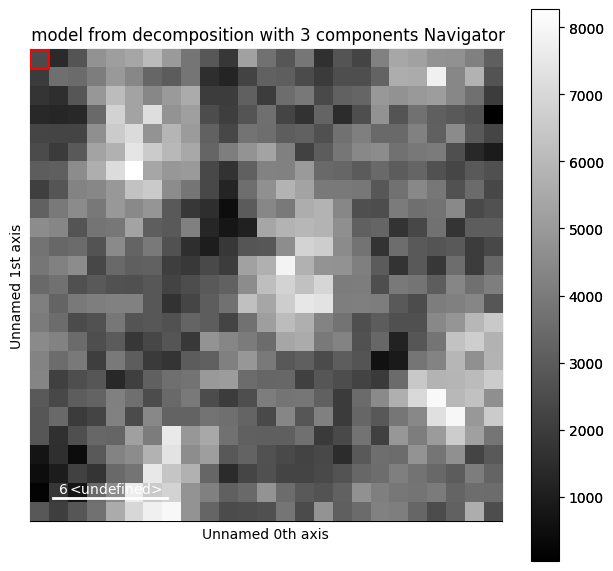

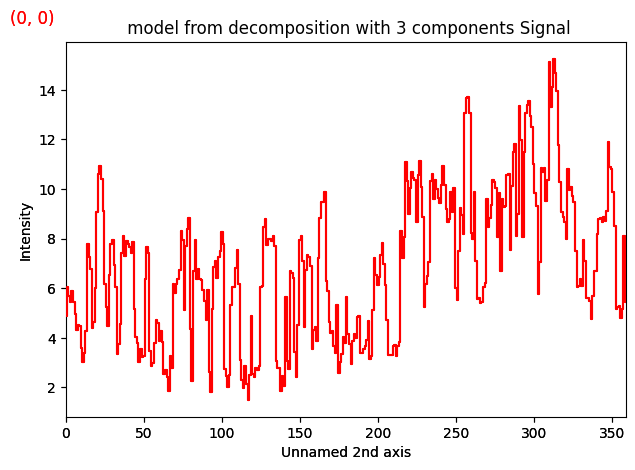

In [10]:
# Setting number of vectors for reconstruction
vectors = 3

# Running auto decomp algorithm, with metrics and plots enabled
clean_ex_nmf = decomp.auto_decomp(data_ex, vectors, algorithm="NMF", output_dimension=5, metrics=True, plots=True)

## Reconstruction Metrics

Three metrics for evaluating the quality of a reconstruction are also available as functions. These are inbuilt to the auto_decomp function and are the values returned when metrics is enabled, but can be individually determined with their respective find_x functions.

### Relative Reconstruction Error (RRE)

RRE is a measure of completeness of reconstruction without compression of the original signal, it represents the deviation between the raw and clean data. It ranges from 0 to 1 and should ideally be a low but non-zero value. Too high a value would represent significant deviation from the original signal and compression occuring in cleaning, whereas at zero there is no error and the raw signal has been returned uncelaned. The formula for calculation is given as:

$$
RRE = \frac{\|x_{orig} - x_{clean}\|_2}{\|x_{orig}\|_2}
$$

The inputs and outputs of the function are given as:

    Parameters
    ----------
    orig: numpy.nparray
        Raw dataset before decomposition.
    clean: numpy.nparray
        Cleaned dataset after decomposition and reconstruction.

    Returns
    -------
    rel_error: float
        Relative reconstruction error of decomposition, see example notebook for details.

Further reading about RRE: https://www.researchgate.net/figure/Plots-of-the-Relative-Reconstruction-Errors-in-the-ROI-using-different-discrete-forward_fig2_263084098

### Explained Variance Ratio (EVR)

EVR is a measure of retained variance of the signal in the process of cleaning. It compares the variance of the vectors used in reconstruction to the raw signal, and again ranges between 0 and 1. At 1, the signal retains all variance and is the same as the raw signal, whereas at 0 it has lost all variance and thus physical meaning. Therefore it is ideal for the EVR to be a high value near 1 but less than 1. The formula for calculating is given below:

$$
EVR = \frac{\sum_{i \in S} \lambda_i}{\sum_{j=1}^{p} \lambda_j}
$$

The EVR theoretically should be an integral of the vectors lambda, however as the reconstruction involves discrete vector sets, a summation is a good approximation. It is important to note that currently this metric is only available for decompositions with the SVD or PCA algorithms, use with another algorithm will return a message relaying this.

The inputs and outputs of the function are given as:

    Parameters
    ----------
    cleaned_data: hs.signals.Signal1D
        Cleaned dataset after decomposition and reconstruction in Hyperspy formatting.
    vectors: int
        Number of vectors in cleaned_data reconstruction.
    algorithm: str
        Algorithm used for decomposition of the dataset.

    Returns
    -------
    evr: float
        Explained variance ratio of decomposition, see example notebook for details.

Further reading about EVR: https://www.sciencedirect.com/topics/computer-science/variance-ratio

### Noise Suppression Metric (NSM)

NSM is a metric to compare the level of noise in the cleaned and raw signals by comparison of the standard deviations. It is similar to a Signal-to-Noise Ratio (SNR), but used over an SNR as this will tend to infinity when examining reconstruction quality, whereas the NSM will provide an approximate demonstration of the noise removed from the system (taking standard deviation to be a relative metric for noise in this instance). The value ranges from 0 to 1, and is described by the formula:

$$
NSM = \frac{\sigma_{clean}}{\sigma_{orig}}
$$

where the standard deviation is given as:

$$
\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2}
$$

The inputs and outputs of the function are given as:

    Parameters
    ----------
    orig: numpy.nparray
        Raw dataset before decomposition.
    clean: numpy.nparray
        Cleaned dataset after decomposition and reconstruction.

    Returns
    -------
    nsr: float
        Noise suppression metric of decomposition, see example notebook for details.

Further reading about NSM: https://www.nature.com/articles/s41598-025-32599-2#:~:text=The%20standard%20deviation%20of%20added,accurate%20signal%20reconstruction%20without%20aliasing.

In [12]:
# Finding the RRE
rre = decomp.find_rre(data_ex.data, clean_ex[0].data)

Relative reconstruction error: 0.15882891074204716


In [14]:
# Finding the EVR
evr = decomp.find_evr(clean_ex[0], vectors, "SVD")

Explained variance ratio: 0.9747733771124947


In [15]:
# Finding the NSM
nsr = decomp.find_nsm(data_ex.data, clean_ex[0].data)

Noise suppression metric: 0.6768237263524621


## Outlier Cleaning

This is a utility function designed to locate and eliminate outlying data points after decomposition and periodic fitting (see TFP_examples). It is primarily used to eliminate values for errors returned by perfit_iterate of extreme value, an artefact of the Scipy optimise process and calculation used to find the errors. It functions by identifying points in a dataset that lie outwith 3 standard deviations of the data mean and cropping them to the 3 STD value. For a dataset x, the function performs:

\begin{equation}
    |x_i|>\overline{x}+\sigma_x \rightarrow |x_i|=\overline{x}+\sigma_x 
\end{equation}

It directly modifies the input dataset for ease of use. The input requirements are:

    Parameter
    ---------
    data: numpy.nparray
        Data for cleaning

    Returns
    -------
    Modifies original input data to the cleaned dataset.
    No direct function returns.

In [16]:
# Applying outlier removal to the reconstructed dataset
decomp.outlier_cleaning(clean_ex[0].data)

## Normalize Intensity

This is another utility function for normalizing the intensity of an input array dataset to values between 1 and 0. It is primarily used for formatting datasets for comparative plotting and analysis. It performs the simple calculation for normalising a set $x$:

\begin{equation}
    x_{norm} = \frac{x-x_{min}}{x_{max}-x_{min}}
\end{equation}

The inputs and outputs are given as:

    Parameter
    ---------
    data: numpy.nparray
        Data to be normalized.

    Returns
    -------
    data_norm: nump.nparray
        Normalized dataset.

In [17]:
# Normalizing intensity of the cleaned dataset
decomp.normalize_intensity(clean_ex[0].data)

array([[[0.27866357, 0.26064951, 0.2780798 , ..., 0.17962655,
         0.1821103 , 0.22548342],
        [0.36760226, 0.34707492, 0.37340012, ..., 0.26901323,
         0.26327336, 0.30369314],
        [0.36587674, 0.35524656, 0.37834651, ..., 0.27748404,
         0.27625911, 0.30637974],
        ...,
        [0.21113772, 0.21167746, 0.2154003 , ..., 0.12637004,
         0.14451383, 0.17461702],
        [0.20957405, 0.2068195 , 0.21287129, ..., 0.12347219,
         0.13862313, 0.17067867],
        [0.24140601, 0.22499282, 0.24075054, ..., 0.14601894,
         0.1496439 , 0.19120951]],

       [[0.36155549, 0.35441096, 0.37773091, ..., 0.27911859,
         0.27784004, 0.30268567],
        [0.3999419 , 0.39801977, 0.41438881, ..., 0.31124157,
         0.31931996, 0.34606654],
        [0.35274425, 0.35820754, 0.37115682, ..., 0.27474803,
         0.28622955, 0.30465325],
        ...,
        [0.22818249, 0.23094782, 0.23321427, ..., 0.14289146,
         0.16331533, 0.19258327],
        [0.2